# California Housing Price Prediction Project:
    This project aims to analyze California housing data and predict median house values using machine learning models
### Goals:
 - Analyze relationships between housing data and median house values
 - Clean data and conduct engineering
 - Compare Linear Regression and Random Forest models
 - Evaluate model performance using RMSE and cross-validation
 - Tune the Random Forest model using GridSearchCV
 - Interpret the final model using feature importance

## 1. Data Loading and Initial Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [2]:
data=pd.read_csv("housing.csv")

## 2. Data Cleaning

The dataset contains missing values in `total_bedrooms`. Since the number of missing observations is small relative to the full dataset, rows containing missing values are removed.

In [3]:
data.dropna(inplace=True)

## 3. Train-Test Split

The target variable is `median_house_value`. The remaining columns are used as input features.

The data is split into 80% training data and 20% testing data. A fixed random state is used to make the results reproducible.

In [4]:
X=data.drop(['median_house_value'],axis=1)
y=data['median_house_value']

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 4. Exploratory Data Analysis

Exploratory data analysis is performed on the training data to identify patterns and relationships between features while keeping the test set unseen.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

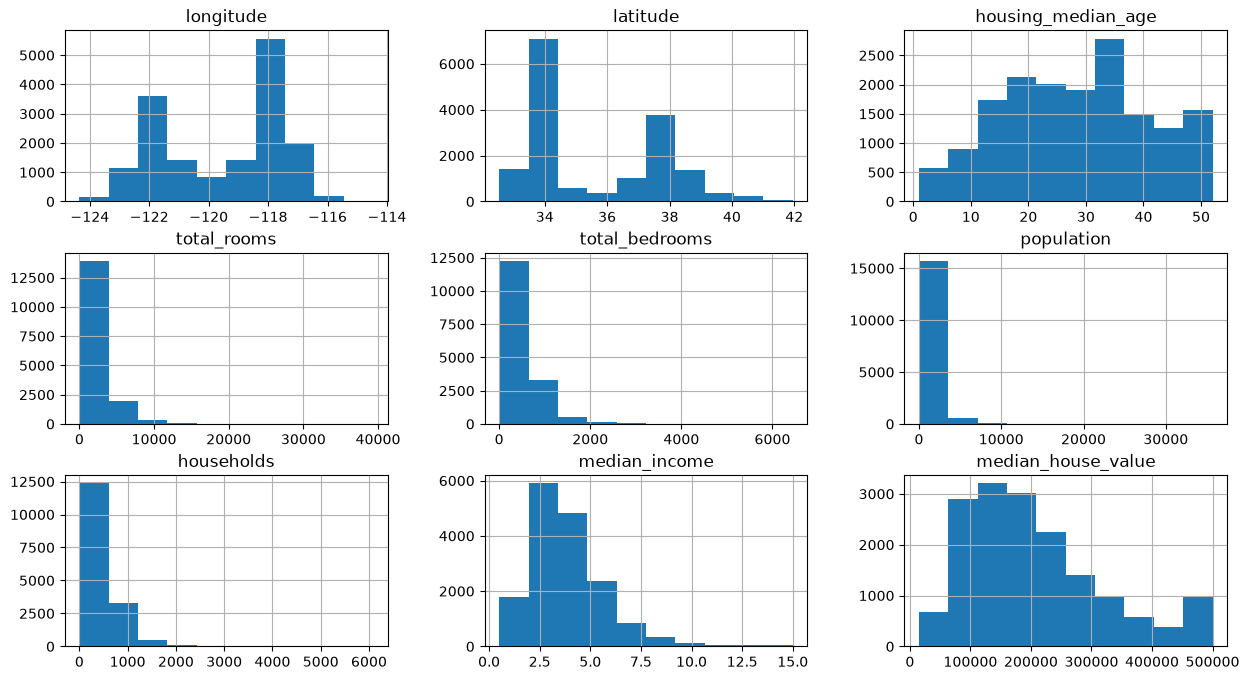

In [5]:
train_data=X_train.join(y_train)

train_data.hist(figsize=(15,8))

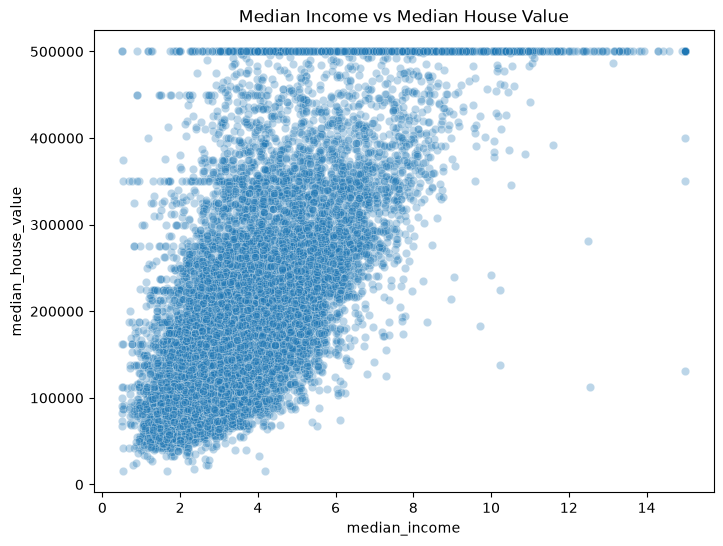

In [6]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="median_income",
    y="median_house_value",
    data=train_data,
    alpha=0.3
)

plt.title("Median Income vs Median House Value")
plt.show()

## Observations

- `median_income` appears strongly related to median house value.
- Several count-based features such as rooms, bedrooms, population, and households are highly skewed.
- Median house values appear capped near $500,000.

## 5. Feature Engineering and Preprocessing

Several new features are created to capture more meaningful relationships between the original variables. Skewed count-based features are log-transformed, and the categorical `ocean_proximity` variable is converted into numeric dummy variables.

In [7]:
def preprocess_features(df):
    df = df.copy()

    df["bedroom_ratio"] = (
        df["total_bedrooms"] / df["total_rooms"]
    )

    df["household_rooms"] = (
        df["total_rooms"] / df["households"]
    )

    df["total_rooms"] = np.log(df["total_rooms"] + 1)
    df["total_bedrooms"] = np.log(df["total_bedrooms"] + 1)
    df["population"] = np.log(df["population"] + 1)
    df["households"] = np.log(df["households"] + 1)

    df = pd.get_dummies(
        df,
        columns=["ocean_proximity"],
        dtype=int
    )

    return df

In [8]:
X_train_processed = preprocess_features(X_train)
X_test_processed = preprocess_features(X_test)

X_test_processed = X_test_processed.reindex(
    columns=X_train_processed.columns,
    fill_value=0
)

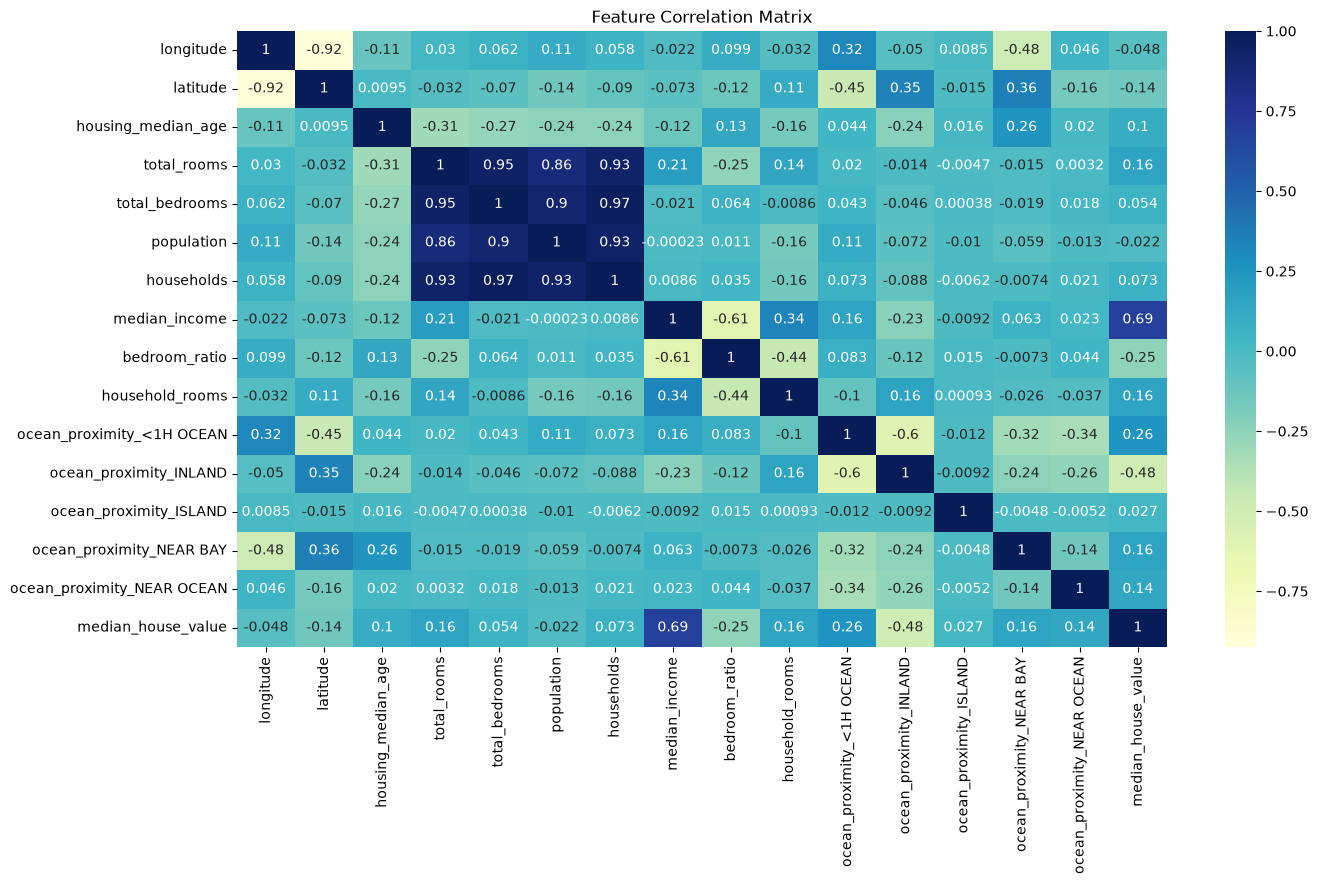

In [9]:
train_processed = X_train_processed.join(y_train)

plt.figure(figsize=(15, 8))

sns.heatmap(
    train_processed.corr(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Feature Correlation Matrix")
plt.show()

## Correlation Findings

- `median_income` has the strongest positive correlation with median house value.
- Inland locations are negatively associated with house values.
- Geographic variables such as longitude and latitude also show meaningful relationships with house value.
- Several housing-count variables are strongly correlated with each other.

## 6. Model Training and Evaluation

Two regression models are evaluated: Linear Regression as a baseline model and Random Forest as a more flexible nonlinear model. Model performance is measured using Root Mean Squared Error (RMSE).

## 6.1 Linear Regression Baseline

Linear Regression is used as a simple baseline to evaluate whether a nonlinear model can provide meaningful improvement.

In [10]:
LR_model = LinearRegression()

LR_model.fit(
    X_train_processed,
    y_train
)

LR_predictions = LR_model.predict(
    X_test_processed
)

LR_mse = mean_squared_error(
    y_test,
    LR_predictions
)

LR_rmse = np.sqrt(LR_mse)

print(f"Linear Regression Test RMSE: ${LR_rmse:,.2f}")

Linear Regression Test RMSE: $67,230.31


## 6.2 Random Forest Regressor

A Random Forest Regressor is trained to capture nonlinear relationships and interactions between housing features.

In [11]:
RFR_model = RandomForestRegressor(
    random_state=42
)

RFR_model.fit(
    X_train_processed,
    y_train
)

RFR_train_predictions = RFR_model.predict(
    X_train_processed
)

RFR_predictions = RFR_model.predict(
    X_test_processed
)

RFR_train_mse = mean_squared_error(
    y_train,
    RFR_train_predictions
)

RFR_mse = mean_squared_error(
    y_test,
    RFR_predictions
)

RFR_train_rmse = np.sqrt(RFR_train_mse)
RFR_rmse = np.sqrt(RFR_mse)

print(f"Random Forest Train RMSE: ${RFR_train_rmse:,.2f}")
print(f"Random Forest Test RMSE:  ${RFR_rmse:,.2f}")

Random Forest Train RMSE: $18,273.80
Random Forest Test RMSE:  $48,837.45


The Random Forest substantially reduces test RMSE compared with Linear Regression. However, the much lower training RMSE suggests that the model is overfitting the training data.

## 7. Cross-Validation

To estimate how well the Random Forest generalizes to unseen data without repeatedly using the test set, 5-fold cross-validation is performed on the training data.

In [12]:
scores = cross_val_score(
    RFR_model,
    X_train_processed,
    y_train,
    scoring="neg_mean_squared_error",
    cv=5
)

cv_rmse = np.sqrt(-scores)

print("RMSE for each fold:", cv_rmse)
print(f"Mean CV RMSE: ${cv_rmse.mean():,.2f}")

RMSE for each fold: [47702.90668775 52365.74397021 48059.66726295 50158.12060404
 50443.86207124]
Mean CV RMSE: $49,746.06


The mean cross-validation RMSE is close to the test RMSE, suggesting that the model's test performance is reasonably representative of its generalization performance.

## 8. Hyperparameter Tuning

GridSearchCV is used to evaluate multiple Random Forest hyperparameter combinations using 5-fold cross-validation.

In [13]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20, None],
    "min_samples_leaf": [1, 2, 4]
}

RFR_grid_model = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    RFR_grid_model,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_search.fit(
    X_train_processed,
    y_train
)

best_cv_rmse = np.sqrt(
    -grid_search.best_score_
)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV RMSE: ${best_cv_rmse:,.2f}")

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV RMSE: $49,596.92


## 9. Final Model Evaluation

The best model identified by GridSearchCV is evaluated once on the held-out test set.

In [14]:
best_RFR_model = grid_search.best_estimator_

best_RFR_predictions = best_RFR_model.predict(
    X_test_processed
)

best_RFR_mse = mean_squared_error(
    y_test,
    best_RFR_predictions
)

best_RFR_rmse = np.sqrt(best_RFR_mse)

print(f"Final Random Forest Test RMSE: ${best_RFR_rmse:,.2f}")

Final Random Forest Test RMSE: $48,771.73


In [15]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Test RMSE": [
        LR_rmse,
        RFR_rmse,
        best_RFR_rmse
    ]
})

model_results

,Model,Test RMSE
0,Linear Regression,67230.308162
1,Random Forest,48837.450458
2,Tuned Random Forest,48771.728532


## 8. Conclusion

The Random Forest model substantially outperformed the Linear Regression baseline.

- Linear Regression RMSE: approximately $67,230
- Default Random Forest RMSE: approximately $48,837
- Tuned Random Forest RMSE: approximately $48,772

The final Random Forest reduced test RMSE by approximately 27% compared with the linear baseline.

Median income was the strongest predictive feature, while geographic variables such as inland location, longitude, and latitude also contributed substantially.

A major limitation of the dataset is the approximately $500,000 ceiling on median house values, which makes high-value districts more difficult to model accurately.